<a href="https://colab.research.google.com/github/asmamirzaei1990/student-manegment-system/blob/main/cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

داده‌های خوشه‌بندی‌شده:
   Student_ID  Study_Hours  Exam_Score  Cluster
0           1            2          50        1
1           2            3          60        1
2           3            4          55        1
3           4            8          90        0
4           5            7          85        0
5           6           10          95        2
6           7           12          99        2
7           8           11          93        2
8           9            6          75        0
9          10            5          65        1


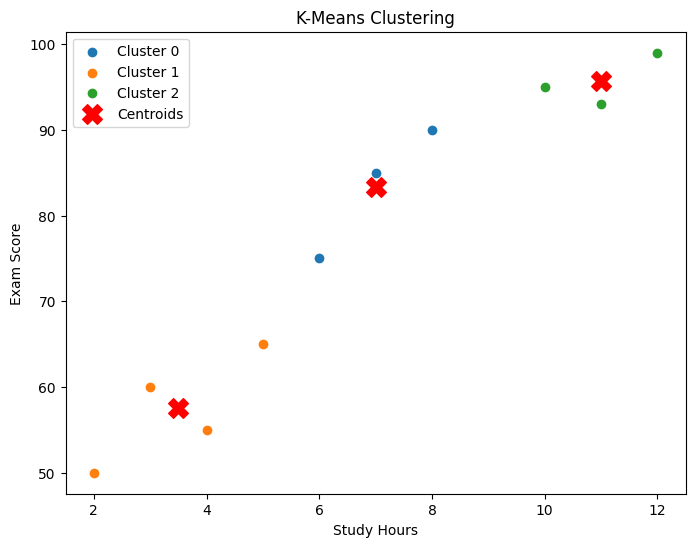

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
data = {
    'Student_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Study_Hours': [2, 3, 4, 8, 7, 10, 12, 11, 6, 5],
    'Exam_Score': [50, 60, 55, 90, 85, 95, 99, 93, 75, 65]
}

df = pd.DataFrame(data)

scaler = StandardScaler()
features = df[['Study_Hours', 'Exam_Score']]
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

print("داده‌های خوشه‌بندی‌شده:")
print(df)

plt.figure(figsize=(8, 6))
for cluster in range(3):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Study_Hours'], cluster_data['Exam_Score'], label=f'Cluster {cluster}')

plt.scatter(kmeans.cluster_centers_[:, 0] * scaler.scale_[0] + scaler.mean_[0],
            kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],
            s=200, c='red', label='Centroids', marker='X')
plt.title('K-Means Clustering')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.show()